# Selection cost and measured read latency

Compare Paper greedy with CPU or GPU sorting and the fixed-width tile selector Saturation, measuring selection through completion of CPU reads.

Fix the profile from Notebook 01 and activation archive from Notebook 02 first. After changing either input or the settings, rerun with `RUN_BENCHMARK = True`. Otherwise, leave it `False` to read the saved CSV and environment record. Dependencies are managed manually; missing or empty results stop execution. Run from this notebook's directory on the target SSD.

In [7]:
from pathlib import Path
from time import perf_counter_ns
from tempfile import TemporaryDirectory
import json, os, platform, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROFILE, MODEL = Path("../01/block_estimates.csv"), Path("../01/latency_model.json")
TRACE, UPSTREAM = Path("../02/activation_traces.npz"), Path("../../../upstream/vlm-flash")
RESULTS, ENVIRONMENT = Path("measured_results.csv"), Path("measured_environment.json")
RUN_BENCHMARK = True
MAX_TRACES_PER_SHAPE = 32
FRACTIONS = np.arange(3, 11) / 10  # paper sparsity 0.7 ... 0.0
WARMUP, REPEATS, THREADS = 3, 30, 6

## Importance and selection cost

Archived importance is $v_i=\operatorname{mean}_{\rm batch,token}|x_i|$ at each projection input. A mask retains $I(M)=\sum_i v_iM_i$. Vectors keep all channels and are normalized to mean one. For shape $N\times d$, a weight row has $w=d\,\text{bytes per weight}/1024$ KiB.

Let $T(z)$ be the median chunk cost over the profile blocks. The efficient length sets the tile width:

$$z_{\rm eff}\in\arg\min_z\frac{T(z)}z,\qquad B=\left\lceil\frac{z_{\rm eff}}w\right\rceil.$$

For offsets $0$ and $\lfloor B/2\rfloor$, Saturation selects the $\lfloor R/B\rfloor$ most important full tiles and the best disjoint residual interval. It keeps the larger $I(M)/\sum_{C\in\mathcal C(M)}T(w|C|)$, with $\mathcal C(M)$ the maximal selected runs. For $R<B$, it selects the best length-$R$ interval.

Paper ranks windows by importance per cost and accepts non-overlapping whole windows within budget. `geometry` sets its windows; the ceiling $z_{99}$ is the first size reaching 99% of peak smoothed training throughput. Both selectors use the measured lookup, with interpolation between lengths, sub-KiB flooring and linear extension beyond the table. The fitted two-line cost and oracle gaps from 02 are unused.

In [8]:
profile = pd.read_csv(PROFILE)
curve = profile.groupby("size_kib").latency_ms.median().sort_index()
boundary = float((curve / curve.index).idxmin())
ceiling = json.loads(MODEL.read_text())["s99_kib"]
display(pd.Series({"Tile boundary (KiB)": boundary, "Paper ceiling (KiB)": ceiling}))

Tile boundary (KiB)    256.0
Paper ceiling (KiB)    256.0
dtype: float64

## Shared native implementation

Paper uses identical candidates for CPU and GPU sorting. Selection time includes GPU score transfer, sorting and return of indices; overlap checks run on CPU. Candidate geometry and cost tables are prepared before timing.

Fresh runs require CUDA, the native reader and the tile selector compiled from `selectors.cpp`. A random blob is written and fsynced on the target filesystem. Reads use each projection's row width, merge adjacent rows, split tasks at 768 KiB and use `THREADS` threads. Buffered fallback is rejected.

In [9]:
if RUN_BENCHMARK:
    import torch
    from torch.utils.cpp_extension import load
    os.environ.setdefault("MAX_JOBS", "1")
    torch.set_num_threads(1)
    sys.path[:0] = [str((UPSTREAM / p).resolve()) for p in ("scripts", "src")]
    import vlmflash
    from vlmflash._native import native
    from vlmflash.policy import _window_sweep
    from profile_flash import write_blob, exclusive
    assert Path(vlmflash.__file__).resolve().is_relative_to(UPSTREAM.resolve())
    reader = native()
    assert reader is not None, "Build the upstream native extension first."
    selectors = load("vlmflash_selection03", [str(Path("selectors.cpp").resolve())],
                     extra_cflags=["-O3", "-std=c++17"], verbose=False)
    table, cuda_available = vlmflash.LatencyTable(curve.to_dict()), torch.cuda.is_available()
    assert cuda_available, "Paper GPU-sort comparison requires CUDA."
    with np.load(TRACE, allow_pickle=False) as archive:
        manifest = json.loads(str(archive["manifest_json"].item()))
        traces = [{**t, "values": archive[t["array"]]} for t in manifest["traces"]]
    groups = [[t for t in traces if t["shape"] == shape] for shape in sorted({t["shape"] for t in traces})]
    traces = [g[i] for g in groups for i in np.linspace(0, len(g)-1,
              min(len(g), MAX_TRACES_PER_SHAPE or len(g)), dtype=int)]
    weight_bytes = {"float16": 2, "bfloat16": 2, "float32": 4}[manifest["model_dtype"]]
    geometry = {"896x128": (8,8), "896x896": (8,8), "896x4864": (8,8), "4864x896": (12,16)}

## Timing a complete repetition

After `WARMUP` rounds, measure `REPEATS` rounds with methods randomly interleaved. Let $t_0$ precede selection, $t_1$ follow selection and $t_2$ follow reader return:

$$t_{\rm selection}=t_1-t_0,\qquad t_{\rm wall}=t_2-t_0.$$

Native `io_ms` covers a nested read/thread interval. Wall time includes reader preparation; component medians are not added. Validation follows timing.

For $R=\max(1,\lfloor fN\rfloor)$, Saturation fills $R$ and Paper may underfill. At $R=N$, all methods bypass selection and read the all-ones mask. Weight transfer to GPU and model computation are outside timing.

In [10]:
if RUN_BENCHMARK:
    rng, records = np.random.default_rng(0), []
    with exclusive("03_paper_saturation"), TemporaryDirectory(dir=RESULTS.parent) as work:
        blob = str(Path(work) / "rows.dat")
        write_blob(blob, max(t["n"] * t["d"] * weight_bytes for t in traces))
        for index, trace in enumerate(traces, 1):
            v = trace["values"].astype(np.float32)
            v = v / v.mean() if v.any() else v
            values, N = torch.from_numpy(v), len(v)
            total_importance = float(values.double().sum())
            row_bytes = weight_bytes * trace["d"]
            w, (start, jump) = row_bytes / 1024, geometry[trace["shape"]]
            B = int(np.ceil(boundary / w))
            costs = torch.tensor([0.] + [table.read_ms(w*r) for r in range(1, N+1)], dtype=torch.float64)
            params = vlmflash.ChunkParams(start_kb=start, step_kb=start, jump_cap_kb=jump,
                                          end_kb=ceiling+1)
            windows, stride = _window_sweep(N, w, table, params)
            sizes = torch.tensor([r for r, _ in windows], dtype=torch.int64)
            delays = torch.tensor([t for _, t in windows], dtype=torch.float64)
            for fraction in FRACTIONS:
                R, dense = max(1, int(round(float(fraction), 6)*N)), torch.ones(N, dtype=torch.uint8)
                functions = {
                    "Paper greedy (GPU sort)": lambda: reader.select_chunks(values, R, sizes, delays, stride, True)[0],
                    "Paper greedy (CPU sort)": lambda: reader.select_chunks(values, R, sizes, delays, stride, False)[0],
                    "Saturation": lambda: selectors.tiles(values, R, costs, B)[0]}
                checked = {}
                for name, fn in functions.items():
                    mask = dense if R == N else fn()
                    selected = int(mask.sum())
                    assert selected <= R if name.startswith("Paper greedy") else selected == R
                    spans = np.flatnonzero(np.diff(np.r_[False, mask.numpy().astype(bool), False])).reshape(-1,2)
                    checked[name] = (mask.clone(), dict(R_selected=selected, fill_pct=100*selected/R,
                        retained_pct=100*float(values[mask.bool()].double().sum())/total_importance if total_importance else np.nan,
                        modeled_io_ms=float(costs[np.diff(spans).ravel()].sum()), runs=len(spans),
                        intervals=json.dumps(spans.tolist())))
                assert torch.equal(checked["Paper greedy (CPU sort)"][0], checked["Paper greedy (GPU sort)"][0])
                for repeat in range(-WARMUP, REPEATS):
                    for name in rng.permutation(list(functions)):
                        begin = perf_counter_ns()
                        mask = dense if R == N else functions[name]()
                        after_select = perf_counter_ns()
                        raw, io_us, _, direct = reader.read_rows(blob, mask, row_bytes, "cpu", THREADS, 768*1024, True)
                        end = perf_counter_ns()
                        assert direct, "O_DIRECT unavailable; refusing page-cache timings."
                        assert torch.equal(mask, checked[name][0])
                        assert raw.shape == (checked[name][1]["R_selected"], row_bytes)
                        if repeat >= 0:
                            records.append(dict(trace_id=trace["trace_id"], shape=trace["shape"],
                                fraction=float(fraction), R_nominal=R, tile_rows=B, method=name, repeat=repeat,
                                selection_ms=(after_select-begin)/1e6, io_ms=io_us/1000,
                                wall_ms=(end-begin)/1e6, **checked[name][1]))
            if index % 16 == 0 or index == len(traces):
                print(f"{index}/{len(traces)} traces measured", flush=True)
    pd.DataFrame(records).to_csv(RESULTS, index=False)
    environment = dict(platform=platform.platform(), torch=torch.__version__, cuda_available=cuda_available,
        paper_sort_devices=["cuda", "cpu"],
        torch_threads=torch.get_num_threads(), reader_threads=THREADS, direct_io=True, destination="cpu",
        tile_boundary_kib=boundary, paper_ceiling_kib=ceiling, traces=len(traces),
        warmup=WARMUP, repeats=REPEATS, fractions=FRACTIONS.tolist(), max_read_kib=768,
        measurement="prepared CPU importance through selected bytes on CPU; no model compute",
        upstream_commit=subprocess.check_output(["git","-C",str(UPSTREAM),"rev-parse","HEAD"],text=True).strip(),
        mount=subprocess.check_output(["findmnt","-T",str(RESULTS.resolve()),"-n","-o","SOURCE,FSTYPE,TARGET"],text=True).strip())
    ENVIRONMENT.write_text(json.dumps(environment, indent=2))
frame = pd.read_csv(RESULTS)
assert not frame.empty, "Run the measurement before evaluating the report."
environment = json.loads(ENVIRONMENT.read_text())
display(pd.Series(environment)[["platform", "torch", "reader_threads", "warmup", "repeats", "traces",
                                "direct_io", "tile_boundary_kib", "paper_ceiling_kib", "mount"]])

creating 8 MB blob at /home/yabsed/Documents/fall26/work/graduate-paper/vlm-in-flash/conclusion/python/results/03/tmpi958r40k/rows.dat
16/128 traces measured
32/128 traces measured
48/128 traces measured
64/128 traces measured
80/128 traces measured
96/128 traces measured
112/128 traces measured
128/128 traces measured


platform             Linux-7.2.5-200.fc44.x86_64-x86_64-with-glibc2.43
torch                                                     2.11.0+cu130
reader_threads                                                       6
warmup                                                               3
repeats                                                             30
traces                                                             128
direct_io                                                         True
tile_boundary_kib                                                256.0
paper_ceiling_kib                                                256.0
mount                                /dev/nvme1n1p3[/home] btrfs /home
dtype: object

## Observed time and retained importance

Take repetition medians within each trace/method/budget first. The table summarizes those cases by shape and method; plotted points take medians across traces at each budget. Retained importance is $100I(M)/\sum_i v_i$, undefined for an all-zero vector.

The panels show wall time against requested retention and retained importance. Paper underfill remains visible through fill percentages; equal requested budgets do not imply equal accuracy.

selection_ms   io_ms  wall_ms  fill_pct
shape    method                                                          
4864x896 Paper greedy (CPU sort)        0.6843  1.2200   1.8347   99.9315
         Paper greedy (GPU sort)        0.7491  1.2220   1.8957   99.9315
         Saturation                     0.0398  1.4364   1.5380  100.0000
896x128  Paper greedy (CPU sort)        0.0210  0.1508   0.1938   98.3240
         Paper greedy (GPU sort)        0.0929  0.1529   0.2633   98.3240
         Saturation                     0.0064  0.1606   0.1896  100.0000
896x4864 Paper greedy (CPU sort)        1.1936  1.2337   2.3472  100.0000
         Paper greedy (GPU sort)        0.7446  1.2192   1.8872  100.0000
         Saturation                     0.0221  1.4431   1.5183  100.0000
896x896  Paper greedy (CPU sort)        0.3235  0.4003   0.7247   99.9069
         Paper greedy (GPU sort)        0.1822  0.3988   0.5870   99.9069
         Saturation                     0.0118  0.4514   0.4935  100.0000

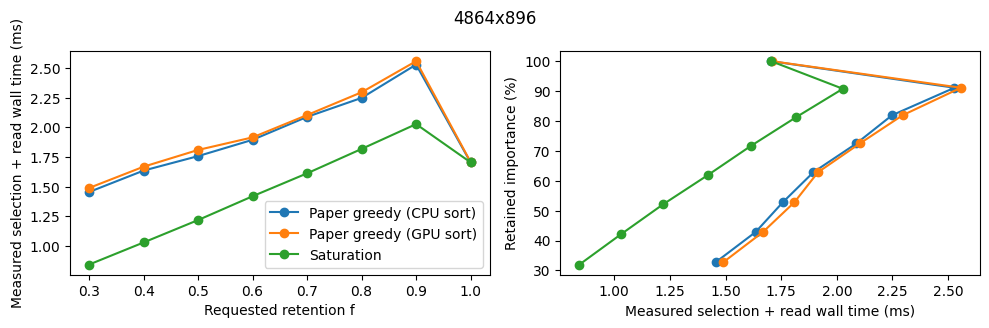

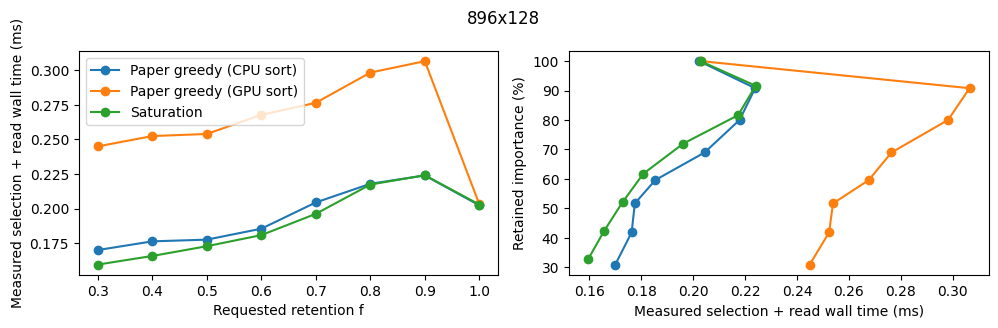

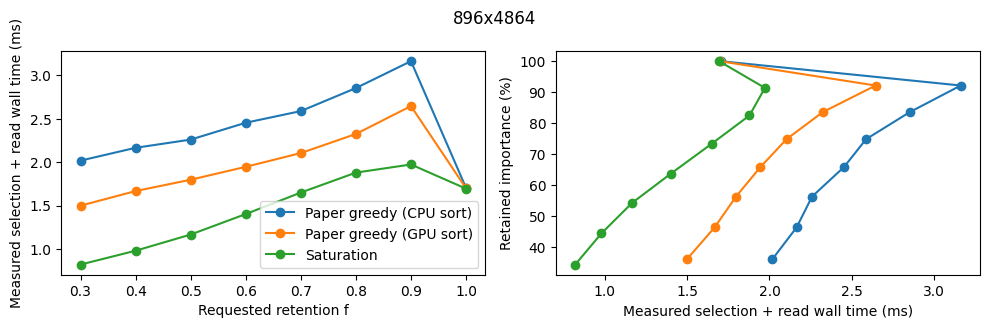

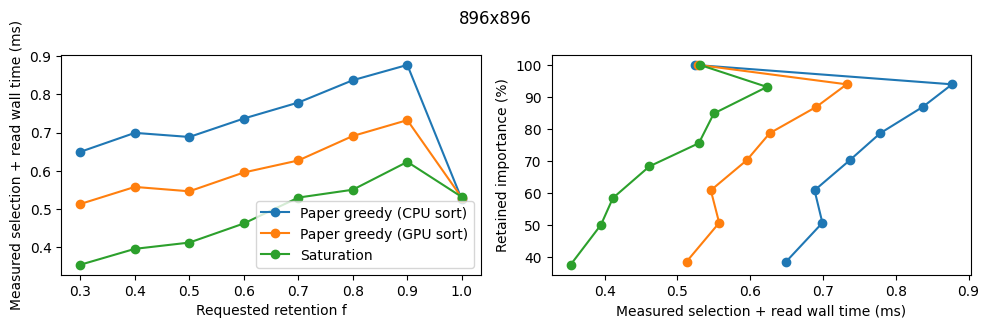

In [11]:
keys = ["shape", "trace_id", "fraction", "method"]
cases = frame.groupby(keys)[["selection_ms","io_ms","wall_ms","retained_pct","fill_pct"]].median().reset_index()
display(cases.groupby(["shape","method"])[["selection_ms","io_ms","wall_ms","fill_pct"]].median().round(4))
for shape, group in cases.groupby("shape"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
    for name, data in group.groupby("method"):
        points = data.groupby("fraction")[["wall_ms","retained_pct"]].median()
        axes[0].plot(points.index, points.wall_ms, "o-", label=name)
        axes[1].plot(points.wall_ms, points.retained_pct, "o-", label=name)
    axes[0].set(xlabel="Requested retention f", ylabel="Measured selection + read wall time (ms)")
    axes[1].set(xlabel="Measured selection + read wall time (ms)", ylabel="Retained importance (%)")
    axes[0].legend()
    fig.suptitle(shape)
    plt.tight_layout()
    plt.show()

## Timing variability of a fixed case

For the first available trace per shape, use the measured budget closest to one half. The table gives 95% BCa intervals for the median from 10,000 bootstrap resamples, alongside the fraction and repetition count. These intervals describe timing variability conditional on this trace and measurement session.

In [12]:
from scipy.stats import bootstrap
intervals = []
for shape, data in frame.groupby("shape"):
    trace = data[data.trace_id == data.trace_id.min()]
    fraction = min(trace.fraction.unique(), key=lambda f: abs(f - .5))
    for name, group in trace[np.isclose(trace.fraction, fraction)].groupby("method"):
        for metric in ("selection_ms", "io_ms", "wall_ms"):
            sample = group[metric].to_numpy()
            ci = bootstrap((sample,), np.median, method="BCa", n_resamples=10000,
                           random_state=0).confidence_interval
            intervals.append(dict(shape=shape, trace_id=int(group.trace_id.iloc[0]), fraction=fraction,
                method=name, metric=metric, n=len(sample), median=np.median(sample), low=ci.low, high=ci.high))
display(pd.DataFrame(intervals).set_index(["shape", "trace_id", "fraction", "method", "metric"]).round(4))

n  median  \
shape    trace_id fraction method                  metric                     
4864x896 6        0.5      Paper greedy (CPU sort) selection_ms  30  0.7221   
                                                   io_ms         30  1.0736   
                                                   wall_ms       30  1.8464   
                           Paper greedy (GPU sort) selection_ms  30  0.7848   
                                                   io_ms         30  1.0548   
                                                   wall_ms       30  1.9031   
                           Saturation              selection_ms  30  0.0437   
                                                   io_ms         30  1.1038   
                                                   wall_ms       30  1.2076   
896x128  1        0.5      Paper greedy (CPU sort) selection_ms  30  0.0243   
                                                   io_ms         30  0.1316   
                                                   wall_ms       30  0.1737   
                           Paper greedy (GPU sort) selection_ms  30  0.3629   
                                                   io_ms         30  0.1323   
                                                   wall_ms       30  0.5269   
                           Saturation              selection_ms  30  0.0071   
                                                   io_ms         30  0.1415   
                                                   wall_ms       30  0.1714   
896x4864 4        0.5      Paper greedy (CPU sort) selection_ms  30  1.1443   
                                                   io_ms         30  1.0602   
                                                   wall_ms       30  2.2648   
                           Paper greedy (GPU sort) selection_ms  30  0.6780   
                                                   io_ms         30  1.0590   
                                                   wall_ms       30  1.7593   
                           Saturation              selection_ms  30  0.0211   
                                                   io_ms         30  1.1085   
                                                   wall_ms       30  1.1650   
896x896  0        0.5      Paper greedy (CPU sort) selection_ms  30  0.3463   
                                                   io_ms         30  0.3318   
                                                   wall_ms       30  0.7145   
                           Paper greedy (GPU sort) selection_ms  30  0.6150   
                                                   io_ms         30  0.3349   
                                                   wall_ms       30  0.9776   
                           Saturation              selection_ms  30  0.0138   
                                                   io_ms         30  0.3632   
                                                   wall_ms       30  0.4053   

                                                                    low  \
shape    trace_id fraction method                  metric                 
4864x896 6        0.5      Paper greedy (CPU sort) selection_ms  0.7142   
                                                   io_ms         1.0620   
                                                   wall_ms       1.8198   
                           Paper greedy (GPU sort) selection_ms  0.7419   
                                                   io_ms         1.0453   
                                                   wall_ms       1.8612   
                           Saturation              selection_ms  0.0412   
                                                   io_ms         1.0952   
                                                   wall_ms       1.1846   
896x128  1        0.5      Paper greedy (CPU sort) selection_ms  0.0207   
                                                   io_ms         0.1261   
                                                   wall_ms       0.1679   
             

## Reading the comparison

The CPU/GPU pair changes sort placement while holding Paper's mask fixed. Saturation changes both selection work and run geometry; the wall-time and importance curves show their combined trade-off.

The profile guides selection, while timing records actual selection and reads. Retained importance is an activation-based proxy; full-model accuracy and inference latency require model execution with the selected weights.